In [1]:
import os
import sys
import torch
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

%matplotlib inline

sys.path.append(os.path.abspath('../src'))
from model import SimpleCNN

## Loading the model

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"We are using: {device}")

MODEL_PATH = '../simplecnn_model4.pth'
IMAGE_PATH = '../img_for_test_grassland_1.jpg'

model = SimpleCNN(num_classes=15)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.to(device)
model.eval()

We are using: cuda


SimpleCNN(
  (features1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (features2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (features3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (features4): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  

## Preparing and viewing the original photo

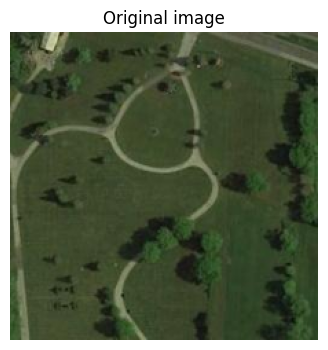

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

img = Image.open(IMAGE_PATH).convert('RGB')
img_tensor = transform(img).unsqueeze(0).to(device)

plt.figure(figsize=(4, 4))
plt.imshow(img.resize((224, 224)))
plt.title("Original image")
plt.axis('off')
plt.show()

## Draw function

In [8]:
with torch.no_grad():
    out1 = model.features1(img_tensor)
    out2 = model.features2(out1)
    out3 = model.features3(out2)
    out4 = model.features4(out3)

def plot_feature_maps(feature_map_tensor, layer_name, num_maps=8):
    maps = feature_map_tensor.squeeze(0).cpu().detach().numpy() 
    num_maps = min(num_maps, maps.shape[0])
    
    fig, axes = plt.subplots(1, num_maps, figsize=(20, 3))
    fig.suptitle(layer_name, fontsize=16, y=1.1)
    
    for i in range(num_maps):
        axes[i].imshow(maps[i], cmap='viridis')
        axes[i].axis('off')
        axes[i].set_title(f'Filter {i+1}')
        
    plt.show()

## How model sees images

Tensor shape at layer 1: torch.Size([1, 16, 112, 112])


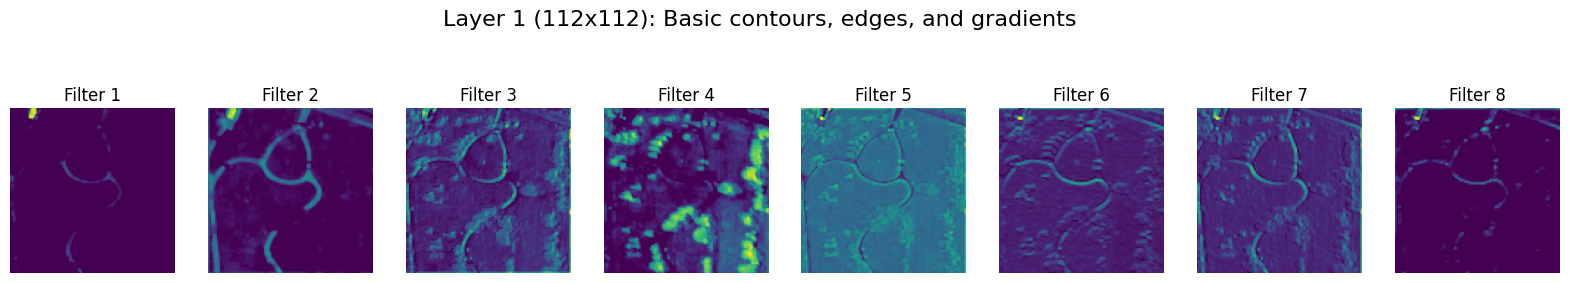

Tensor shape at layer 2: torch.Size([1, 32, 56, 56])


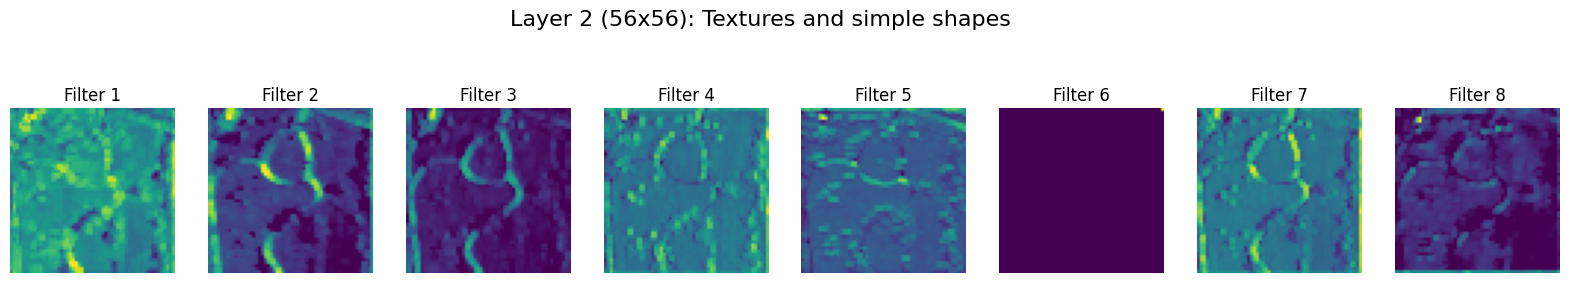

Tensor shape at layer 3: torch.Size([1, 64, 28, 28])


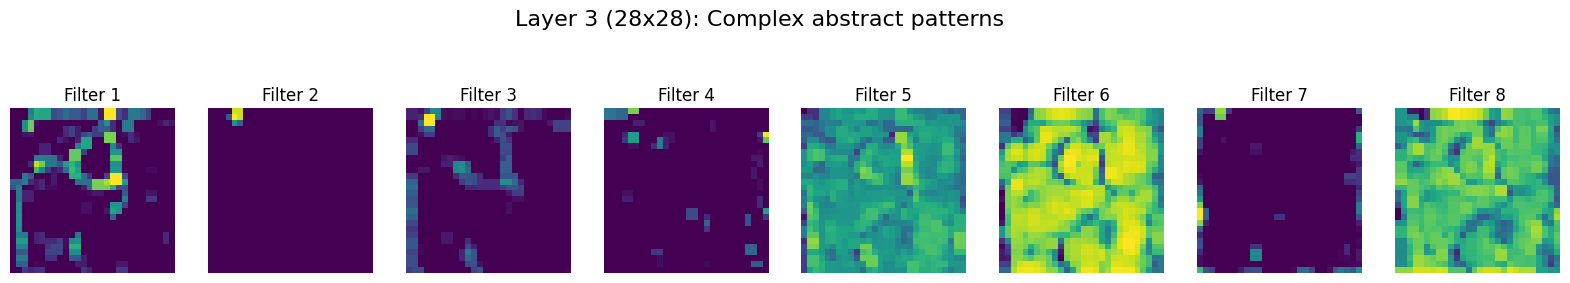

Tensor shape at layer 4: torch.Size([1, 128, 14, 14])


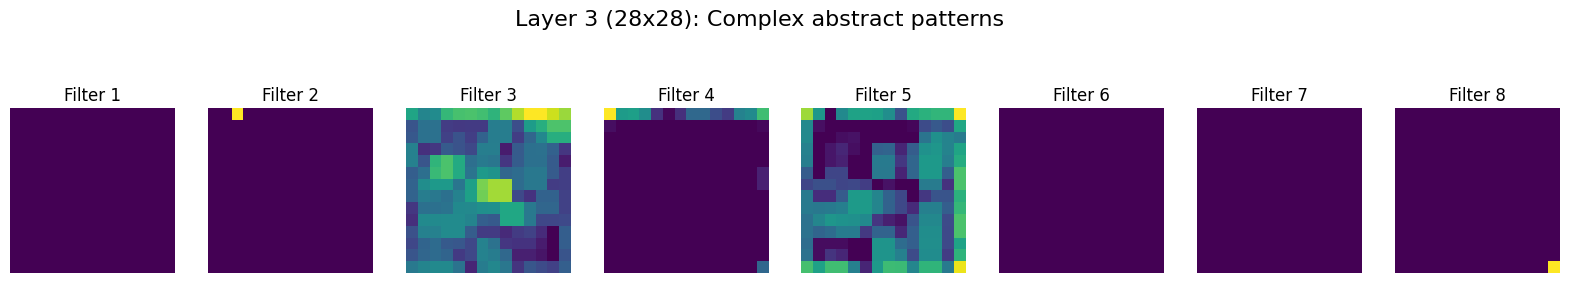

In [9]:
print(f"Tensor shape at layer 1: {out1.shape}")
plot_feature_maps(out1, layer_name="Layer 1 (112x112): Basic contours, edges, and gradients", num_maps=8)

print(f"Tensor shape at layer 2: {out2.shape}")
plot_feature_maps(out2, layer_name="Layer 2 (56x56): Textures and simple shapes", num_maps=8)

print(f"Tensor shape at layer 3: {out3.shape}")
plot_feature_maps(out3, layer_name="Layer 3 (28x28): Complex abstract patterns", num_maps=8)

print(f"Tensor shape at layer 4: {out4.shape}")
plot_feature_maps(out4, layer_name="Layer 3 (28x28): Complex abstract patterns", num_maps=8)

We built an tool to see exactly how our SimpleCNN processes an image. By extracting feature maps from all three convolutional layers, we watched the network break down a Grassland photograph. Layer 1 successfully acted as an edge detector, highlighting the sharp contrast of a winding walking path. Layer 2 compressed these geometric shapes, while Layer 3 and 4 turned the image into highly abstract, low-resolution semantic heatmaps.